STEP 1: DATA COLLECTION

STEP 2: PREPROCESSING

STEP 2.1 DATA CHECKING

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd


# Load RAW dataset
df = pd.read_csv('/content/drive/MyDrive/2.0 Machine Learning project 2.0/mobile_price_range_data.csv')

print("===== RAW DATA CHECK =====")
print("Initial dataset shape:", df.shape)

# Check missing values
missing_total = df.isnull().sum().sum()
print("Total missing values detected:", missing_total)

# Check duplicate rows
duplicate_total = df.duplicated().sum()
print("Total duplicate rows detected:", duplicate_total)

#total problematic rows
print("Total problematic rows:",duplicate_total+ missing_total)

===== RAW DATA CHECK =====
Initial dataset shape: (2000, 21)
Total missing values detected: 0
Total duplicate rows detected: 0
Total problematic rows: 0


STEP 2.2 DATA CLEANING

In [ ]:
import pandas as pd


# 1. Remove missing values
df = df.dropna()

# 2. Remove duplicate rows
df = df.drop_duplicates()

# Show final cleaned shape
print("Cleaned dataset shape:", df.shape)

# Optional: preview
df.head()


Cleaned dataset shape: (2000, 21)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


STEP 2.3 VERFIY FEATURE UNIT

In [ ]:
for col in df.columns:
    print(f"\n===== {col} =====")
    try:
        print(df[col].describe())
    except:
        print("Non-numeric column")


===== battery_power =====
count    2000.000000
mean     1238.518500
std       439.418206
min       501.000000
25%       851.750000
50%      1226.000000
75%      1615.250000
max      1998.000000
Name: battery_power, dtype: float64

===== blue =====
count    2000.0000
mean        0.4950
std         0.5001
min         0.0000
25%         0.0000
50%         0.0000
75%         1.0000
max         1.0000
Name: blue, dtype: float64

===== clock_speed =====
count    2000.000000
mean        1.522250
std         0.816004
min         0.500000
25%         0.700000
50%         1.500000
75%         2.200000
max         3.000000
Name: clock_speed, dtype: float64

===== dual_sim =====
count    2000.000000
mean        0.509500
std         0.500035
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: dual_sim, dtype: float64

===== fc =====
count    2000.000000
mean        4.309500
std         4.341444
min         0.000000
25%         1.000000
50%

STEP 2.4 UNIT CONVERSTION

In [ ]:
df['ram'] = df['ram'] / 1024


STEP 2.5 EDA EXPLORATORY DATA ANALYSIS

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   float64
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  

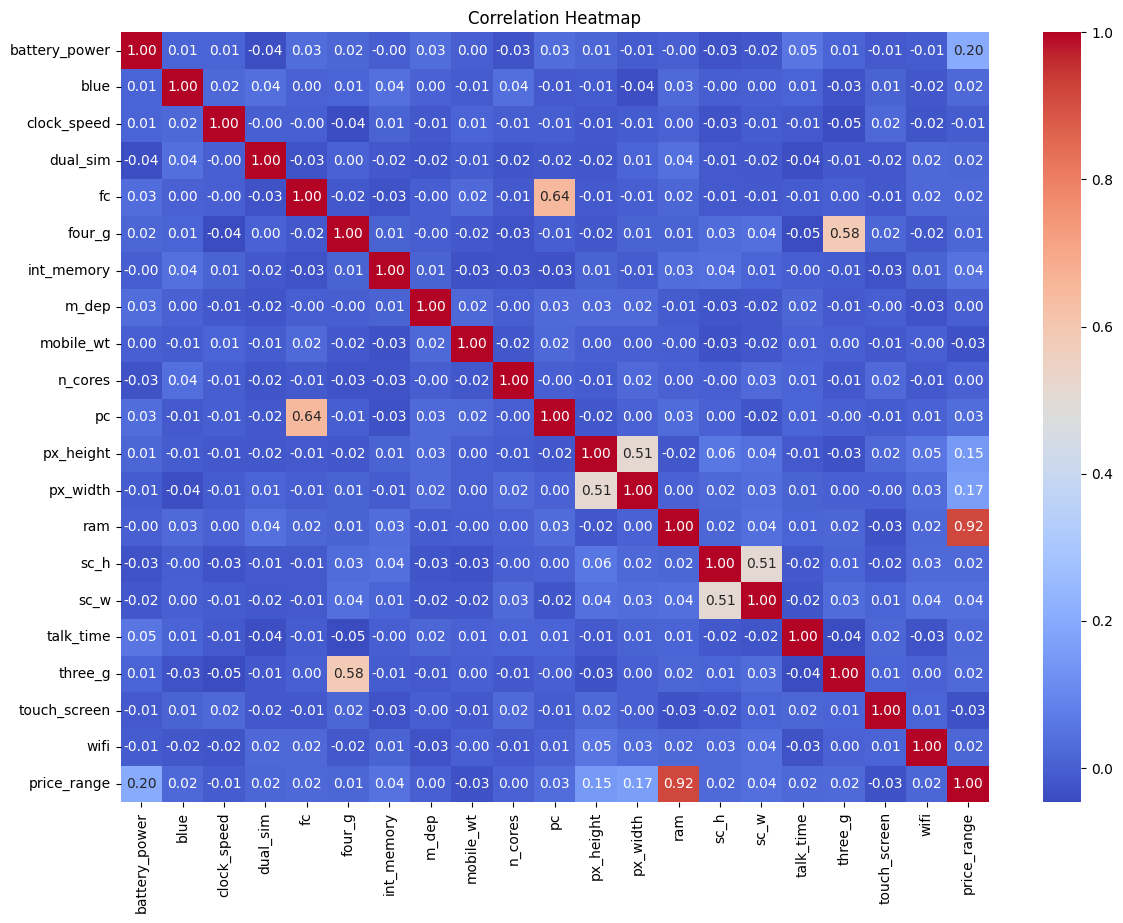


Outlier summary:
               outlier_count
three_g                  477
fc                        18
px_height                  2
battery_power              0
blue                       0
dual_sim                   0
clock_speed                0
m_dep                      0
four_g                     0
mobile_wt                  0
n_cores                    0
pc                         0
int_memory                 0
px_width                   0
ram                        0
sc_w                       0
sc_h                       0
talk_time                  0
touch_screen               0
wifi                       0
price_range                0


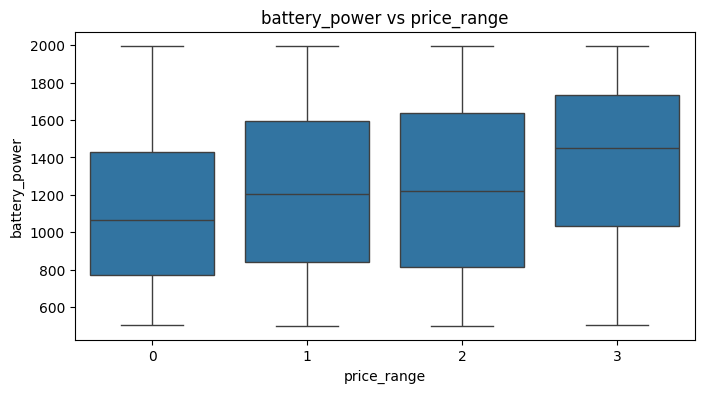

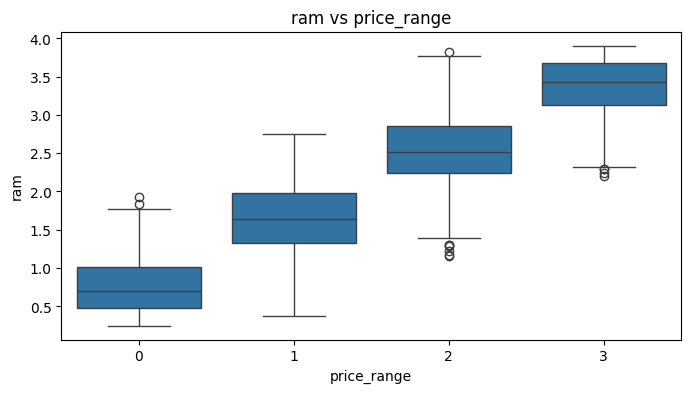

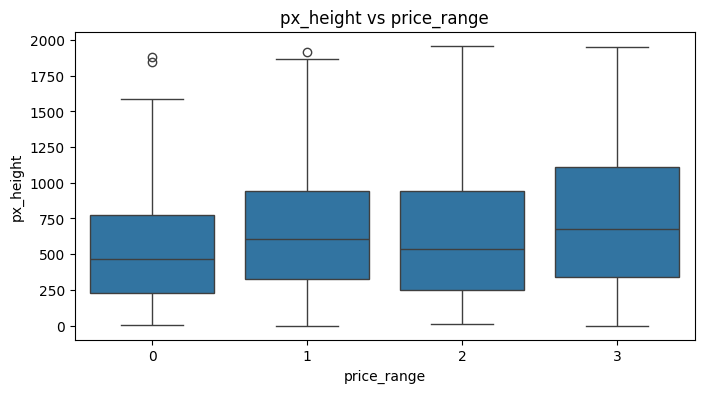

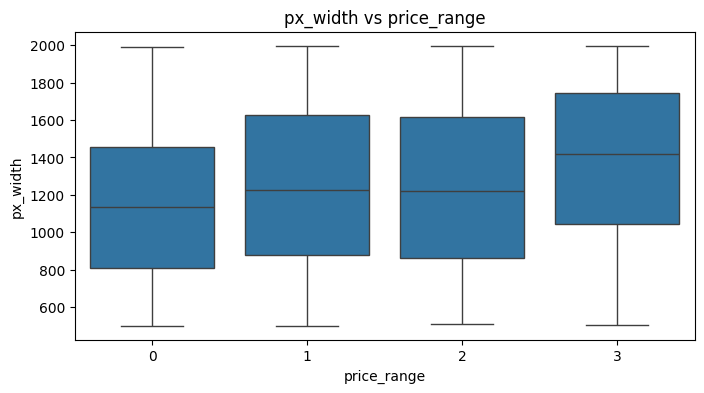

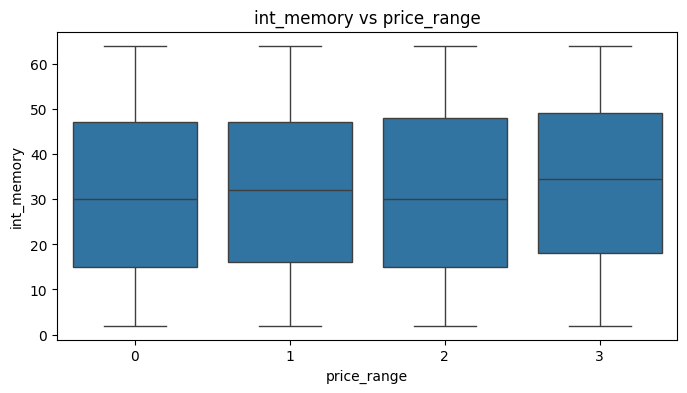

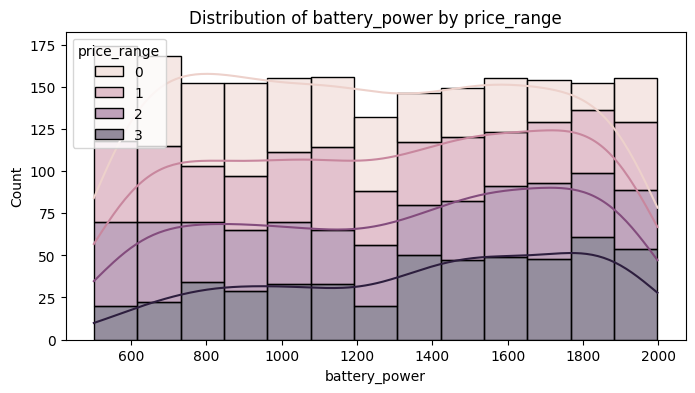

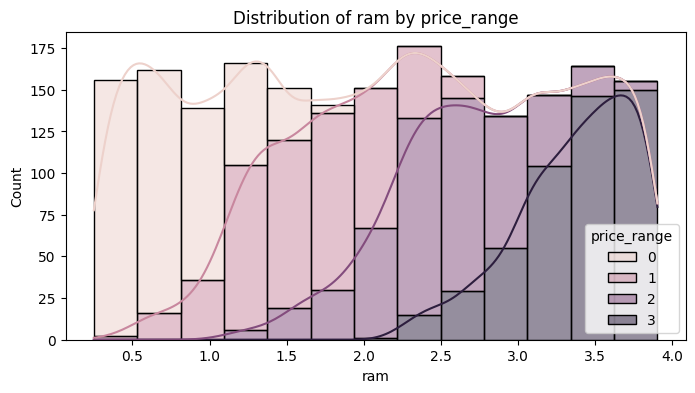

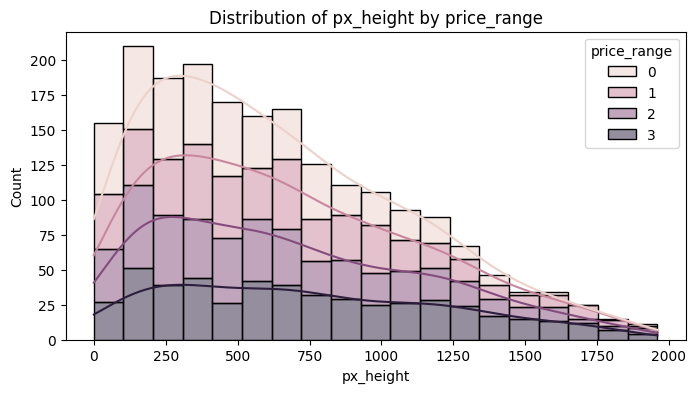

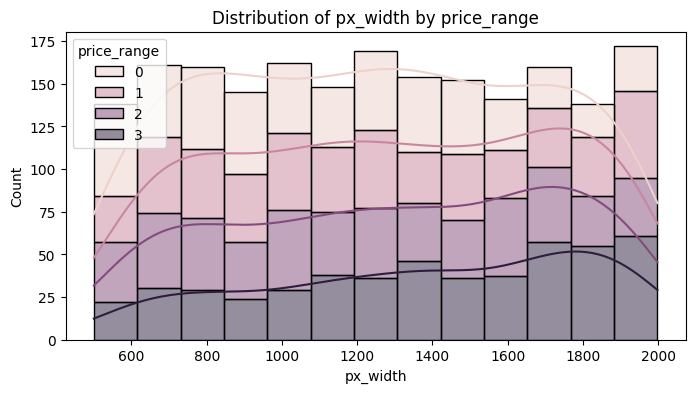

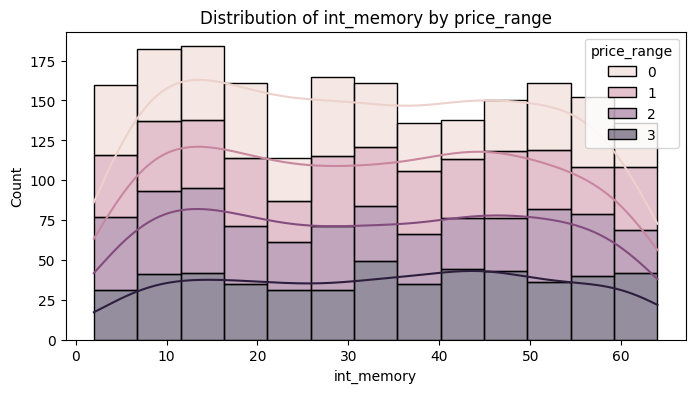

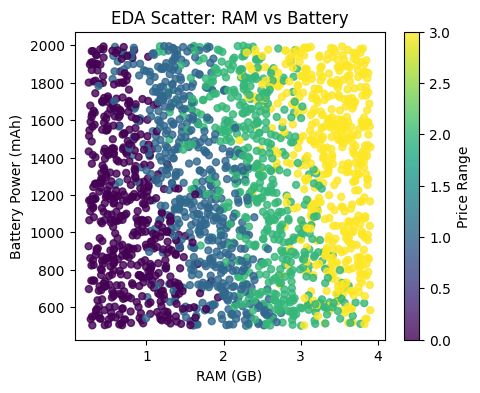

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# DATASET INFO
print("Dataset Info:")
print(df.info())

# Missing values check
print("\nMissing values per column:")
print(df.isna().sum())

#STATISTICal SUMMARY
print("\nStatistical Summary:")
print(df.describe())

#TARGET DISTRIBUTION (PRICE RANGE)
print("\nTarget Distribution (price_range):")
print(df['price_range'].value_counts())



# Correlation Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Outlier detection (IQR)
outlier_count = {}

num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count[col] = ((df[col] < lower) | (df[col] > upper)).sum()

outlier_df = pd.DataFrame.from_dict(outlier_count, orient='index', columns=['outlier_count'])
print("\nOutlier summary:")
print(outlier_df.sort_values(by='outlier_count', ascending=False))


# Key features vs price_range
key_features = ['battery_power', 'ram', 'px_height', 'px_width', 'int_memory']

for col in key_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='price_range', y=col, data=df)
    plt.title(f'{col} vs price_range')
    plt.show()

for col in key_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, hue='price_range', multiple='stack', kde=True)
    plt.title(f'Distribution of {col} by price_range')
    plt.show()


# Features
x = df['ram']          # RAM (already converted)
y = df['battery_power']
c = df['price_range']  # color mapping

plt.figure(figsize=(5, 4))

scatter = plt.scatter(
    x, y,
    c=c,
    cmap='viridis',
    s=25,#og size 15
    alpha=0.8
)

plt.xlabel("RAM (GB)")
plt.ylabel("Battery Power (mAh)")
plt.title("EDA Scatter: RAM vs Battery")

# Colorbar instead of legend (KEY difference)
cbar = plt.colorbar(scatter)
cbar.set_label("Price Range")

plt.show()


STEP 2.6 FEATURE ENGINEERING

In [ ]:
import numpy as np
import pandas as pd

# REQUIRE: df loaded & cleaned
assert 'df' in globals(), "DataFrame 'df' not found. Load/clean data first."

# Make a local copy reference (operations inplace on df)
# Ensure numeric types where needed
num_cols = ['ram','int_memory','px_height','px_width','sc_h','sc_w','battery_power','mobile_wt']
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# 1) Ensure ram in GB (heuristic)
if 'ram' in df.columns:
    # if median > 50 -> values likely in MB
    if df['ram'].median(skipna=True) > 50:
        df['ram'] = df['ram'] / 1024.0

# 2) Ensure int_memory exists
if 'int_memory' not in df.columns:
    df['int_memory'] = 0.0
else:
    df['int_memory'] = df['int_memory'].fillna(0.0)

# 3) Resolution (total pixels) — requires px_height & px_width
if {'px_height','px_width'}.issubset(df.columns):
    df['resolution'] = (df['px_height'].astype(float) * df['px_width'].astype(float)).fillna(0.0)
else:
    df['resolution'] = 0.0

# 4) PPI — only if px_height, px_width and sc_h (screen diagonal in inches) exist
if {'px_height','px_width','sc_h'}.issubset(df.columns):
    sc_h_safe = df['sc_h'].replace(0, np.nan).fillna(df['sc_h'].median(skipna=True))
    df['ppi'] = np.sqrt(df['px_height'].astype(float)**2 + df['px_width'].astype(float)**2) / sc_h_safe
    df['ppi'] = df['ppi'].fillna(df['ppi'].median(skipna=True))
else:
    # create ppi with zeros so downstream code won't break
    df['ppi'] = 0.0

# 5) Battery / performance combos — guard each column
if 'battery_power' in df.columns and 'mobile_wt' in df.columns:
    wt_safe = df['mobile_wt'].replace(0, np.nan).fillna(df['mobile_wt'].median(skipna=True))
    df['battery_efficiency'] = (df['battery_power'].astype(float) / wt_safe).fillna(0.0)
else:
    df['battery_efficiency'] = 0.0

if 'ram' in df.columns and 'int_memory' in df.columns:
    df['ram_int_ratio'] = (df['ram'].astype(float) / (df['int_memory'].astype(float) + 1e-6)).replace([np.inf, -np.inf], 0).fillna(0.0)
else:
    df['ram_int_ratio'] = 0.0

if 'ram' in df.columns and 'battery_power' in df.columns:
    df['ram_battery_combo'] = (df['ram'].astype(float) * df['battery_power'].astype(float)).fillna(0.0)
else:
    df['ram_battery_combo'] = 0.0

# 6) Res area (resolution * sc_w) if sc_w present
if 'resolution' in df.columns and 'sc_w' in df.columns:
    df['res_area'] = (df['resolution'].astype(float) * df['sc_w'].astype(float)).fillna(0.0)
else:
    df['res_area'] = 0.0

# 7) Binned RAM level (0..3) — safe bins for ram in GB
if 'ram' in df.columns:
    df['ram_level'] = pd.cut(df['ram'].astype(float),
                             bins=[-1, 1, 3, 6, np.inf],
                             labels=[0,1,2,3]).astype(float).fillna(0).astype(int)
else:
    df['ram_level'] = 0

# 8) Log transforms for skewed features (guard negatives/nans)
for col in ['battery_power','ram','resolution']:
    if col in df.columns:
        df[f'log_{col}'] = np.log1p(df[col].astype(float).clip(lower=0)).fillna(0.0)
    else:
        df[f'log_{col}'] = 0.0

# 9) Drop any temporary helpers if present (none added permanently)
# (No helper columns were added to df permanently)

# 10) Final sanity: fill remaining NaNs in new features with 0
new_features = ['resolution','ppi','battery_efficiency','ram_int_ratio','ram_battery_combo','res_area','ram_level','log_battery_power','log_ram','log_resolution']
for c in new_features:
    if c in df.columns:
        df[c] = df[c].fillna(0.0)

# 11) Summary (concise)
added = [c for c in new_features if c in df.columns]
print("Added features:", added)
print("New shape:", df.shape)
print(df[added].head())


Added features: ['resolution', 'ppi', 'battery_efficiency', 'ram_int_ratio', 'ram_battery_combo', 'res_area', 'ram_level', 'log_battery_power', 'log_ram', 'log_resolution']
New shape: (2000, 31)
   resolution         ppi  battery_efficiency  ram_int_ratio  \
0     15120.0   84.029389            4.478723       0.355608   
1   1799140.0  128.488269            7.507353       0.048478   
2   2167308.0  193.698774            3.882759       0.062000   
3   2171776.0  135.041255            4.694656       0.270410   
4   1464096.0  213.900094           12.914894       0.031317   

   ram_battery_combo    res_area  ram_level  log_battery_power   log_ram  \
0        2095.955078    105840.0          1           6.736967  1.249689   
1        2623.291992   5397420.0          1           6.929517  1.272380   
2        1431.141602   4334616.0          1           6.335054  1.264689   
3        1663.022461  17374208.0          1           6.423247  1.309441   
4        2509.209961   2928192.0        

STEP 2.7 ENCODING TARGET

In [ ]:
# Encoding target
import pandas as pd
from sklearn.preprocessing import LabelEncoder

assert 'df' in globals() and 'price_range' in df.columns, "DataFrame 'df' with column 'price_range' required."

# Helper: ensure no missing targets
if df['price_range'].isna().any():
    raise ValueError("Missing values found in 'price_range' — handle them before encoding.")

# Case 1: already proper integer labels 0..3
unique_vals = set(pd.Series(df['price_range'].unique()).astype(object))
if pd.api.types.is_integer_dtype(df['price_range']) and unique_vals.issubset({0, 1, 2, 3}):
    df['price_range'] = df['price_range'].astype(int)

else:
    # Case 2: string/categorical labels -> LabelEncoder
    if df['price_range'].dtype == object or pd.api.types.is_categorical_dtype(df['price_range']):
        le = LabelEncoder()
        df['price_range'] = le.fit_transform(df['price_range']).astype(int)

    # Case 3: numeric but not 0..3 (continuous or >4 classes) -> quantile bin into 4 classes
    elif pd.api.types.is_numeric_dtype(df['price_range']):
        if df['price_range'].nunique() > 4:
            df['price_range'] = pd.qcut(df['price_range'], 4, labels=False).astype(int)
        else:
            # Map distinct numeric values to 0..(k-1)
            vals = sorted(df['price_range'].unique())
            mapping = {v: i for i, v in enumerate(vals)}
            df['price_range'] = df['price_range'].map(mapping).astype(int)

# Final safety: ensure labels are 0..3 (if fewer classes, they will be in range 0..k-1)
min_label, max_label = int(df['price_range'].min()), int(df['price_range'].max())
if max_label > 3:
    raise ValueError(f"Encoded labels exceed 3 (got {min_label}-{max_label}). Inspect 'price_range' values.")

print("price_range classes distribution:\n", df['price_range'].value_counts().sort_index())


price_range classes distribution:
 price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64


STEP 2.8 TRAIN/TEST DATA SPLIT (80%-20%)

In [ ]:
# datat split
from sklearn.model_selection import train_test_split

# Split features and target
X = df.drop(columns=['price_range'])
y = df['price_range']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train shape :", X_train.shape)
print("Test shape  :", X_test.shape)


Train shape : (1600, 30)
Test shape  : (400, 30)


STEP 2.9 STANDARDAIZATION

In [ ]:
#standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
scaler.fit(X_train)

# Transform both datasets
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Standardization complete.")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)


'''Standardization code = Z-score scaling code.

Your features become:

mean = 0

std = 1

This is Z-score.'''

Standardization complete.
X_train_scaled: (1600, 30)
X_test_scaled : (400, 30)


'Standardization code = Z-score scaling code.\n\nYour features become:\n\nmean = 0\n\nstd = 1\n\nThis is Z-score.'

STEP 3: TRAIN MODEL

In [ ]:

# ===== Step 8/9: Train all 5 models (clearly labeled blocks) =====
# REQUIRE: X_train, X_test, y_train, y_test exist.
# Prefer using standardized data: X_train_scaled, X_test_scaled.
# Fallback: use X_train / X_test if scaled versions aren't present.

import joblib
import numpy as np
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# choose data (scaled preferred)
if 'X_train_scaled' in globals() and 'X_test_scaled' in globals():
    Xtr = X_train_scaled
    Xte = X_test_scaled
else:
    Xtr = X_train.values if hasattr(X_train, "values") else X_train
    Xte = X_test.values if hasattr(X_test, "values") else X_test

# ensure y are numpy arrays
ytr = y_train.values if hasattr(y_train, "values") else y_train
yte = y_test.values if hasattr(y_test, "values") else y_test

model_results = {}

# ---------------------------
# Train: Linear Classifier (SGDClassifier - linear)
# ---------------------------
print("\n" + "="*30)
print("Training: Linear Classifier (SGDClassifier - linear)")
print("="*30)

linear_clf = SGDClassifier(loss="squared_hinge", penalty="l2", random_state=42, max_iter=5000, tol=1e-4)
linear_clf.fit(Xtr, ytr)
pred_linear = linear_clf.predict(Xte)

acc_linear = accuracy_score(yte, pred_linear)
print("Linear Classifier Accuracy:", round(acc_linear,4))
print("Confusion Matrix:\n", confusion_matrix(yte, pred_linear))
print("Classification Report:\n", classification_report(yte, pred_linear, zero_division=0))

model_results['LinearClassifier'] = {'model': linear_clf, 'accuracy': acc_linear}
joblib.dump(linear_clf, "model_linear_clf.pkl")

# ---------------------------
# Train: Logistic Regression (classification)
# ---------------------------
print("\n" + "="*30)
print("Training: Logistic Regression")
print("="*30)

logreg = LogisticRegression(max_iter=5000, random_state=42)
logreg.fit(Xtr, ytr)
pred_logreg = logreg.predict(Xte)

acc_logreg = accuracy_score(yte, pred_logreg)
print("Logistic Regression Accuracy:", round(acc_logreg,4))
print("Confusion Matrix:\n", confusion_matrix(yte, pred_logreg))
print("Classification Report:\n", classification_report(yte, pred_logreg, zero_division=0))

model_results['LogisticRegression'] = {'model': logreg, 'accuracy': acc_logreg}
joblib.dump(logreg, "model_logistic_regression.pkl")

# ---------------------------
# Train: Decision Tree Classifier
# ---------------------------
print("\n" + "="*30)
print("Training: Decision Tree Classifier")
print("="*30)

dt = DecisionTreeClassifier(criterion="entropy", random_state=42)

dt.fit(Xtr, ytr)
pred_dt = dt.predict(Xte)

acc_dt = accuracy_score(yte, pred_dt)
print("Decision Tree Accuracy:", round(acc_dt,4))
print("Confusion Matrix:\n", confusion_matrix(yte, pred_dt))
print("Classification Report:\n", classification_report(yte, pred_dt, zero_division=0))

model_results['DecisionTree'] = {'model': dt, 'accuracy': acc_dt}
joblib.dump(dt, "model_decision_tree.pkl")

# ---------------------------
# Train: Random Forest Classifier
# ---------------------------
print("\n" + "="*30)
print("Training: Random Forest Classifier")
print("="*30)

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(Xtr, ytr)
pred_rf = rf.predict(Xte)

acc_rf = accuracy_score(yte, pred_rf)
print("Random Forest Accuracy:", round(acc_rf,4))
print("Confusion Matrix:\n", confusion_matrix(yte, pred_rf))
print("Classification Report:\n", classification_report(yte, pred_rf, zero_division=0))

model_results['RandomForest'] = {'model': rf, 'accuracy': acc_rf}
joblib.dump(rf, "model_random_forest.pkl")

# ---------------------------
# Train: K-Nearest Neighbors (KNN)
# ---------------------------
print("\n" + "="*30)
print("Training: K-Nearest Neighbors (KNN)")
print("="*30)

knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(Xtr, ytr)
pred_knn = knn.predict(Xte)

acc_knn = accuracy_score(yte, pred_knn)
print("KNN Accuracy:", round(acc_knn,4))
print("Confusion Matrix:\n", confusion_matrix(yte, pred_knn))
print("Classification Report:\n", classification_report(yte, pred_knn, zero_division=0))

model_results['KNN'] = {'model': knn, 'accuracy': acc_knn}
joblib.dump(knn, "model_knn.pkl")

# ---------------------------
# Summary: Best model by accuracy on test set
# ---------------------------
print("\n" + "="*30)
best_name = max(model_results, key=lambda k: model_results[k]['accuracy'])
best_acc = model_results[best_name]['accuracy']
print(f"BEST MODEL (by test accuracy): {best_name} with accuracy = {round(best_acc,4)}")
print("="*30)

# model_results dict contains models and accuracies for programmatic use



Training: Linear Classifier (SGDClassifier - linear)
Linear Classifier Accuracy: 0.915
Confusion Matrix:
 [[98  2  0  0]
 [ 2 83 15  0]
 [ 0 12 88  0]
 [ 0  0  3 97]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       100
           1       0.86      0.83      0.84       100
           2       0.83      0.88      0.85       100
           3       1.00      0.97      0.98       100

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.92      0.92       400


Training: Logistic Regression
Logistic Regression Accuracy: 0.9525
Confusion Matrix:
 [[97  3  0  0]
 [ 4 93  3  0]
 [ 0  2 94  4]
 [ 0  0  3 97]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97       100
           1       0.95      0.93      0.94       100
           2       0.94      0.94     

STEP 4: HYPERPARAMETER TUNING

In [ ]:
# ===== Hyperparameter tuning for the 5 allowed models =====
# REQUIRE: X_train, y_train exist (from train_test_split)
# Uses pipelines for models that require scaling.
# Produces: best_estimators dict, cv_results dict, and saves best models with joblib.

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import joblib
import numpy as np

assert 'X_train' in globals() and 'y_train' in globals(), "Run train_test_split first."

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
n_jobs = -1
verbose = 1

best_estimators = {}
cv_results = {}


# ------------------------
# 1) Linear classifier (SGDClassifier)
# ------------------------
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
import joblib

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SGDClassifier(random_state=42, max_iter=5000, tol=1e-4))
])

param_grid_linear = {
    "clf__loss": ["log_loss", "hinge", "squared_hinge"],  # FIXED HERE
    "clf__penalty": ["l2", "l1", "elasticnet"],
    "clf__alpha": [1e-4, 1e-3, 1e-2],
    "clf__l1_ratio": [0.15, 0.5]   # used only when penalty='elasticnet'
}

gs_linear = GridSearchCV(
    pipe_linear,
    param_grid_linear,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
    refit=True
)

gs_linear.fit(X_train, y_train)

best_estimators = {}
cv_results = {}

best_estimators["LinearClassifier"] = gs_linear.best_estimator_
cv_results["LinearClassifier"] = gs_linear.best_score_

print(
    "LinearClassifier best:",
    gs_linear.best_params_,
    round(gs_linear.best_score_, 4)
)

joblib.dump(gs_linear.best_estimator_, "best_linear_clf.pkl")

# ------------------------
# 2) Logistic Regression
# ------------------------
pipe_log = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, random_state=42))
])
param_grid_log = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__penalty": ["l2"],    # keep simple/stable
    "clf__solver": ["lbfgs", "saga"]
}
gs_log = GridSearchCV(pipe_log, param_grid_log, cv=cv, scoring="accuracy",
                      n_jobs=n_jobs, verbose=verbose, refit=True)
gs_log.fit(X_train, y_train)
best_estimators['LogisticRegression'] = gs_log.best_estimator_
cv_results['LogisticRegression'] = gs_log.best_score_
print("LogisticRegression best:", gs_log.best_params_, round(gs_log.best_score_,4))
joblib.dump(gs_log.best_estimator_, "best_logistic_regression.pkl")

# ------------------------
# 3) Decision Tree
# ------------------------
dt = DecisionTreeClassifier(criterion="entropy", random_state=42)

param_grid_dt = {
    "max_depth": [None, 5, 10, 15, 25],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}
gs_dt = GridSearchCV(
    dt,
    param_grid_dt,
    cv=cv,
    scoring="accuracy",
    n_jobs=n_jobs,
    verbose=verbose,
    refit=True
)
gs_dt.fit(X_train, y_train)
best_estimators['DecisionTree'] = gs_dt.best_estimator_
cv_results['DecisionTree'] = gs_dt.best_score_
print("DecisionTree (Entropy) best:", gs_dt.best_params_, round(gs_dt.best_score_, 4))
joblib.dump(gs_dt.best_estimator_, "best_decision_tree.pkl")

# ------------------------
# 4) Random Forest
# ------------------------
rf = RandomForestClassifier(random_state=42, n_jobs=1)  # n_jobs handled by GridSearchCV
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [2, 5]
}
gs_rf = GridSearchCV(rf, param_grid_rf, cv=cv, scoring="accuracy",
                     n_jobs=n_jobs, verbose=verbose, refit=True)
gs_rf.fit(X_train, y_train)
best_estimators['RandomForest'] = gs_rf.best_estimator_
cv_results['RandomForest'] = gs_rf.best_score_
print("RandomForest best:", gs_rf.best_params_, round(gs_rf.best_score_,4))
joblib.dump(gs_rf.best_estimator_, "best_random_forest.pkl")

# ------------------------
# 5) K-Nearest Neighbors (pipeline with scaler)
# ------------------------
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])
param_grid_knn = {
    "knn__n_neighbors": [3, 5, 7, 9],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2]   # Manhattan (1) or Euclidean (2)
}
gs_knn = GridSearchCV(pipe_knn, param_grid_knn, cv=cv, scoring="accuracy",
                      n_jobs=n_jobs, verbose=verbose, refit=True)
gs_knn.fit(X_train, y_train)
best_estimators['KNN'] = gs_knn.best_estimator_
cv_results['KNN'] = gs_knn.best_score_
print("KNN best:", gs_knn.best_params_, round(gs_knn.best_score_,4))
joblib.dump(gs_knn.best_estimator_, "best_knn.pkl")

# ------------------------
# Summary: best by CV score
# ------------------------
best_name = max(cv_results, key=cv_results.get)
best_score = cv_results[best_name]
print("\nBEST (by CV accuracy):", best_name, round(best_score,4))

# Save summary results
joblib.dump(best_estimators, "best_estimators_all_models.pkl")
print("Saved all best estimators and individual best models to disk.")


Fitting 5 folds for each of 54 candidates, totalling 270 fits
LinearClassifier best: {'clf__alpha': 0.001, 'clf__l1_ratio': 0.15, 'clf__loss': 'hinge', 'clf__penalty': 'l1'} 0.9181
Fitting 5 folds for each of 8 candidates, totalling 40 fits
LogisticRegression best: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'} 0.95
Fitting 5 folds for each of 45 candidates, totalling 225 fits
DecisionTree (Entropy) best: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2} 0.865
Fitting 5 folds for each of 24 candidates, totalling 120 fits
RandomForest best: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100} 0.9062
Fitting 5 folds for each of 16 candidates, totalling 80 fits
KNN best: {'knn__n_neighbors': 9, 'knn__p': 1, 'knn__weights': 'distance'} 0.785

BEST (by CV accuracy): LogisticRegression 0.95
Saved all best estimators and individual best models to disk.


STEP 5: EVALUATION AND COMPARISON

STEP 5.1: CROSS VALIDATION COMPARISON

In [ ]:
# ===== Cross-Validation Comparison for All 5 Tuned Models =====
from sklearn.model_selection import cross_validate, StratifiedKFold
import pandas as pd

assert 'best_estimators' in globals(), "Run hyperparameter tuning first."

# Same CV folds for all models
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Scoring metrics (use string names)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro"
}

cv_summary = {}

print("\n===== CROSS-VALIDATION COMPARISON (ALL 5 MODELS) =====")

for model_name, model in best_estimators.items():
    print(f"\nEvaluating Model: {model_name}")

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        verbose=0,
        return_train_score=False
    )

    cv_summary[model_name] = {
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1 Score": scores["test_f1"].mean()
    }

# Display results sorted by F1 score
cv_df = pd.DataFrame(cv_summary).T
cv_df_sorted = cv_df.sort_values(by="F1 Score", ascending=False)

print("\n===== CV RESULTS (Sorted by F1 Score) =====")
print(cv_df_sorted)

best_model_name = cv_df_sorted.index[0]
print(f"\nBEST MODEL (by CV F1): {best_model_name}")



===== CROSS-VALIDATION COMPARISON (ALL 5 MODELS) =====

Evaluating Model: LinearClassifier

Evaluating Model: LogisticRegression

Evaluating Model: DecisionTree

Evaluating Model: RandomForest

Evaluating Model: KNN

===== CV RESULTS (Sorted by F1 Score) =====
                    Accuracy  Precision    Recall  F1 Score
LogisticRegression  0.950000   0.951089  0.950000  0.949928
LinearClassifier    0.918125   0.919231  0.918125  0.918233
RandomForest        0.906250   0.907588  0.906250  0.906392
DecisionTree        0.865000   0.867476  0.865000  0.865179
KNN                 0.785000   0.790832  0.785000  0.786556

BEST MODEL (by CV F1): LogisticRegression


STEP 5.2: FINALE TEST EVALUATION

STEP 5.2.1: CONFUSION MATRIX WITH CLASSIFICATION REPORT OF ALL MODEL

In [ ]:
# ===== Confusion Matrices for ALL 5 Tuned Models =====
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import pandas as pd

assert 'best_estimators' in globals(), "Run hypertuning first."

print("\n===== CONFUSION MATRIX FOR ALL MODELS =====")

all_confusions = {}

for name, model in best_estimators.items():
    print("\n" + "="*40)
    print(f"Model: {name}")
    print("="*40)

    # Predict on test set
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print("Test Accuracy:", round(acc, 4))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Store confusion matrix for later use
    all_confusions[name] = cm

# Optional: Convert all confusion matrices into a readable dict/DataFrame form
print("\n\n===== STORED CONFUSION MATRICES (dictionary format) =====")
for name, cm in all_confusions.items():
    print(f"\n{name}:\n{cm}")



===== CONFUSION MATRIX FOR ALL MODELS =====

Model: LinearClassifier
Test Accuracy: 0.9275

Confusion Matrix:
[[99  1  0  0]
 [ 2 85 13  0]
 [ 0 10 90  0]
 [ 0  0  3 97]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       100
           1       0.89      0.85      0.87       100
           2       0.85      0.90      0.87       100
           3       1.00      0.97      0.98       100

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400


Model: LogisticRegression
Test Accuracy: 0.975

Confusion Matrix:
[[100   0   0   0]
 [  1  96   3   0]
 [  0   3  96   1]
 [  0   0   2  98]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       100
           1       0.97      0.96      0.96       100
           2       0.95      0.96     

STEP 5.2.2: Visual representation of confusion matrix


STEP 5.2.2.1: Logistic Regression

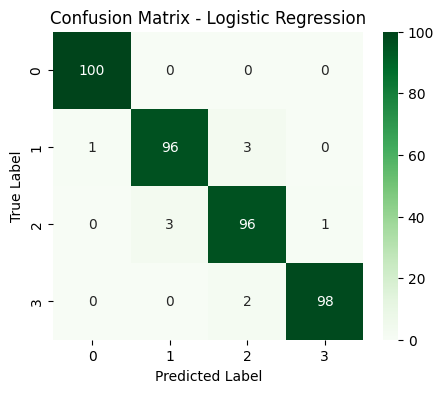

In [ ]:
#Logistic Regression (BEST MODEL)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model = best_estimators["LogisticRegression"]
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


STEP 5.2.2.2: SGD Linear Classifier

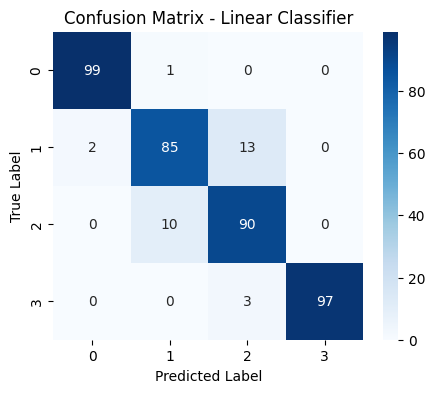

In [ ]:
#linear classifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model = best_estimators["LinearClassifier"]
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
plt.title("Confusion Matrix - Linear Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


STEP 5.2.2.3:  Decision Tree

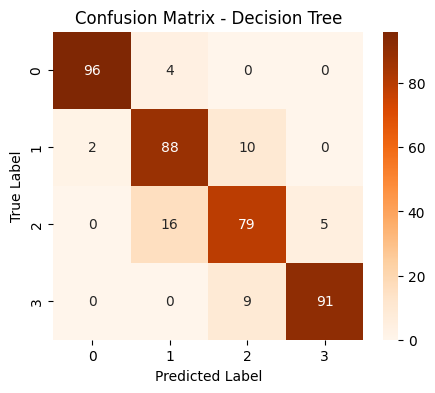

In [ ]:
#decision tree
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model = best_estimators["DecisionTree"]
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


STEP 5.2.2.4: Random Forest

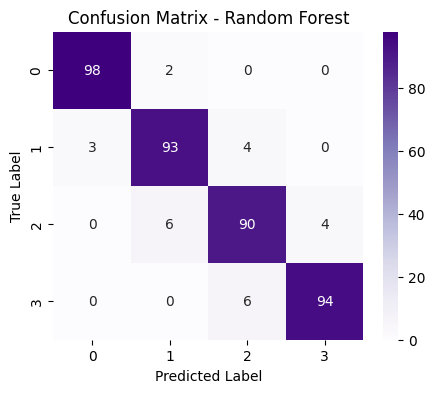

In [ ]:
#random forest
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model = best_estimators["RandomForest"]
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


STEP 5.2.2.5: KNN

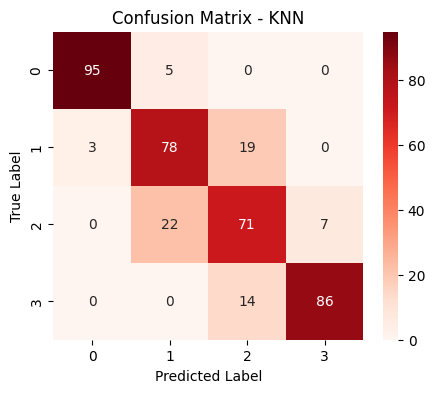

In [ ]:
#KNN
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model = best_estimators["KNN"]
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


STEP 5.2.3: Classification report for best model

In [ ]:
# ===== CLASSIFICATION REPORT FOR BEST MODEL =====
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# best model name and model
print(f"\n=== BEST MODEL SELECTED AFTER CV: {best_model_name} ===")

best_model = best_estimators[best_model_name]

# predict on test set
y_pred = best_model.predict(X_test)

print("\n=== FINAL TEST ACCURACY ===")
print(round(accuracy_score(y_test, y_pred), 4))

print("\n=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, zero_division=0))

print("\nThis is the final evaluation of the BEST model:", best_model_name)



=== BEST MODEL SELECTED AFTER CV: LogisticRegression ===

=== FINAL TEST ACCURACY ===
0.975

=== CONFUSION MATRIX ===
[[100   0   0   0]
 [  1  96   3   0]
 [  0   3  96   1]
 [  0   0   2  98]]

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       100
           1       0.97      0.96      0.96       100
           2       0.95      0.96      0.96       100
           3       0.99      0.98      0.98       100

    accuracy                           0.97       400
   macro avg       0.98      0.97      0.97       400
weighted avg       0.98      0.97      0.97       400


This is the final evaluation of the BEST model: LogisticRegression


STEP 5.2.4: TEST ACCURACY

In [ ]:
# ===== FINAL TEST ACCURACY COMPARISON FOR ALL 5 TUNED MODELS =====
# This code evaluates every tuned model on X_test and prints:
# - Model name
# - Test accuracy
# - Best model overall

from sklearn.metrics import accuracy_score

assert 'best_estimators' in globals(), "Run hypertuning first."

test_scores = {}

print("\n===== FINAL TEST ACCURACY OF ALL MODELS =====")

for name, model in best_estimators.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    test_scores[name] = acc
    print(f"{name}: {round(acc, 4)}")

# Find best model
best_model_test = max(test_scores, key=test_scores.get)
best_accuracy_test = test_scores[best_model_test]

print("\n===== BEST MODEL ON TEST SET =====")
print(f"Model: {best_model_test}")
print(f"Accuracy: {round(best_accuracy_test, 4)}")



===== FINAL TEST ACCURACY OF ALL MODELS =====
LinearClassifier: 0.9275
LogisticRegression: 0.975
DecisionTree: 0.885
RandomForest: 0.9375
KNN: 0.825

===== BEST MODEL ON TEST SET =====
Model: LogisticRegression
Accuracy: 0.975


STEP 5.3: Feature Importance


STEP 5.3.1: SGD LINEAR CLASSIFIER

               feature  importance
28             log_ram   30.248502
13                 ram   27.948111
24   ram_battery_combo   14.894745
0        battery_power    5.036839
20          resolution    4.210560
12            px_width    3.826374
11           px_height    2.277176
27   log_battery_power    2.144642
8            mobile_wt    1.934329
26           ram_level    1.876597
22  battery_efficiency    1.466716
29      log_resolution    0.933696
6           int_memory    0.777490
25            res_area    0.503814
10                  pc    0.377940
14                sc_h    0.354097
19                wifi    0.350210
23       ram_int_ratio    0.308812
9              n_cores    0.308546
5               four_g    0.251391
16           talk_time    0.161655
1                 blue    0.158415
4                   fc    0.140041
18        touch_screen    0.112106
21                 ppi    0.088269
17             three_g    0.078410
7                m_dep    0.078070
2          clock_spe

/tmp/ipython-input-485102218.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_lin["importance"], y=df_lin["feature"], palette="Oranges_r")


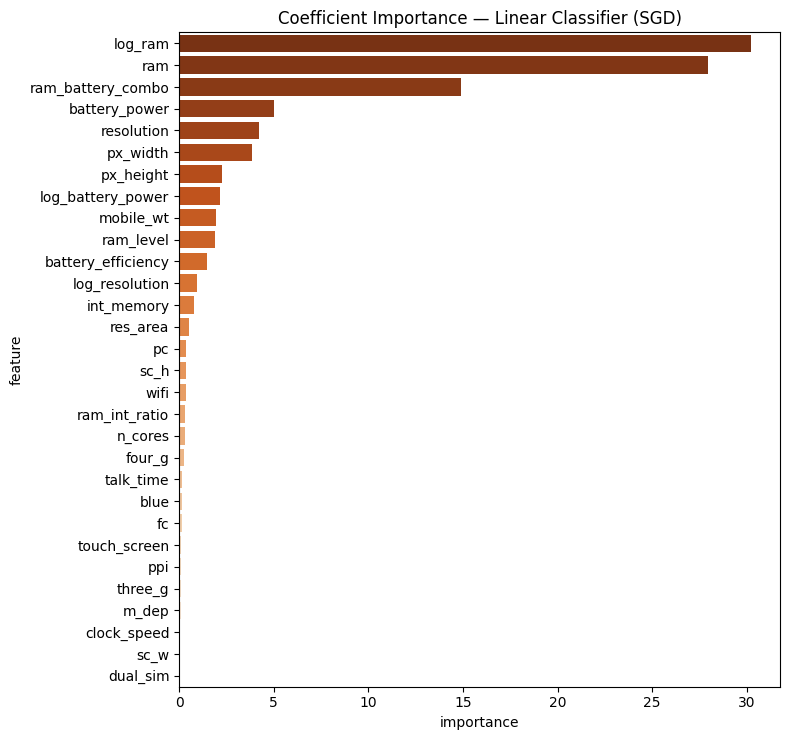

In [ ]:
# ===== COEFFICIENT IMPORTANCE — LINEAR CLASSIFIER (SGD) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline

lin_est = best_estimators["LinearClassifier"]
lin_core = lin_est.steps[-1][1] if isinstance(lin_est, Pipeline) else lin_est

coef = np.abs(lin_core.coef_).mean(axis=0)

df_lin = pd.DataFrame({
    "feature": X_train.columns,
    "importance": coef
}).sort_values("importance", ascending=False)

print(df_lin)

plt.figure(figsize=(8, max(4, 0.25 * len(df_lin))))
sns.barplot(x=df_lin["importance"], y=df_lin["feature"], palette="Oranges_r")
plt.title("Coefficient Importance — Linear Classifier (SGD)")
plt.tight_layout()
plt.show()


STEP 5.3.2: LOGISTIC REGRESSION

               feature  importance
13                 ram    9.356206
28             log_ram    7.416611
24   ram_battery_combo    4.236829
0        battery_power    3.143003
12            px_width    2.654901
11           px_height    2.077707
20          resolution    1.237077
27   log_battery_power    0.795068
6           int_memory    0.621377
26           ram_level    0.608785
8            mobile_wt    0.596146
22  battery_efficiency    0.581739
14                sc_h    0.398043
23       ram_int_ratio    0.381859
19                wifi    0.306148
10                  pc    0.274194
21                 ppi    0.268502
9              n_cores    0.265579
29      log_resolution    0.257107
1                 blue    0.160666
4                   fc    0.157885
18        touch_screen    0.132280
2          clock_speed    0.120056
17             three_g    0.104562
16           talk_time    0.104297
25            res_area    0.092469
5               four_g    0.077182
3             dual_s

/tmp/ipython-input-1482438527.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_log["importance"], y=df_log["feature"], palette="Purples_r")


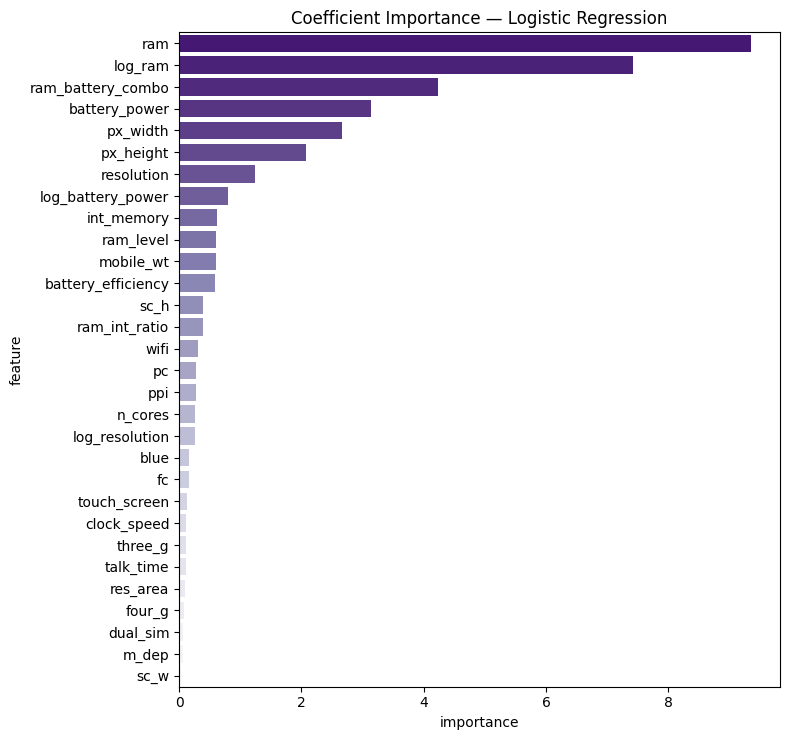

In [ ]:
# ===== COEFFICIENT IMPORTANCE — LOGISTIC REGRESSION =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline

# extract core estimator (last step of pipeline)
log_est = best_estimators["LogisticRegression"]
log_core = log_est.steps[-1][1] if isinstance(log_est, Pipeline) else log_est

coef = np.abs(log_core.coef_).mean(axis=0)

df_log = pd.DataFrame({
    "feature": X_train.columns,
    "importance": coef
}).sort_values("importance", ascending=False)

print(df_log)

plt.figure(figsize=(8, max(4, 0.25 * len(df_log))))
sns.barplot(x=df_log["importance"], y=df_log["feature"], palette="Purples_r")
plt.title("Coefficient Importance — Logistic Regression")
plt.tight_layout()
plt.show()


STEP 5.3.4: DECISION TREE

               feature  importance
28             log_ram    0.374297
24   ram_battery_combo    0.253261
13                 ram    0.149485
29      log_resolution    0.087909
12            px_width    0.033196
20          resolution    0.031609
22  battery_efficiency    0.015282
11           px_height    0.009231
6           int_memory    0.006334
4                   fc    0.005943
25            res_area    0.005566
21                 ppi    0.004226
10                  pc    0.004218
8            mobile_wt    0.003838
15                sc_w    0.002348
23       ram_int_ratio    0.002265
16           talk_time    0.002133
27   log_battery_power    0.002053
14                sc_h    0.001886
0        battery_power    0.001794
7                m_dep    0.001587
2          clock_speed    0.001541
9              n_cores    0.000000
1                 blue    0.000000
3             dual_sim    0.000000
5               four_g    0.000000
18        touch_screen    0.000000
19                wi

/tmp/ipython-input-2398972896.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_dt["importance"], y=df_dt["feature"], palette="Blues_r")


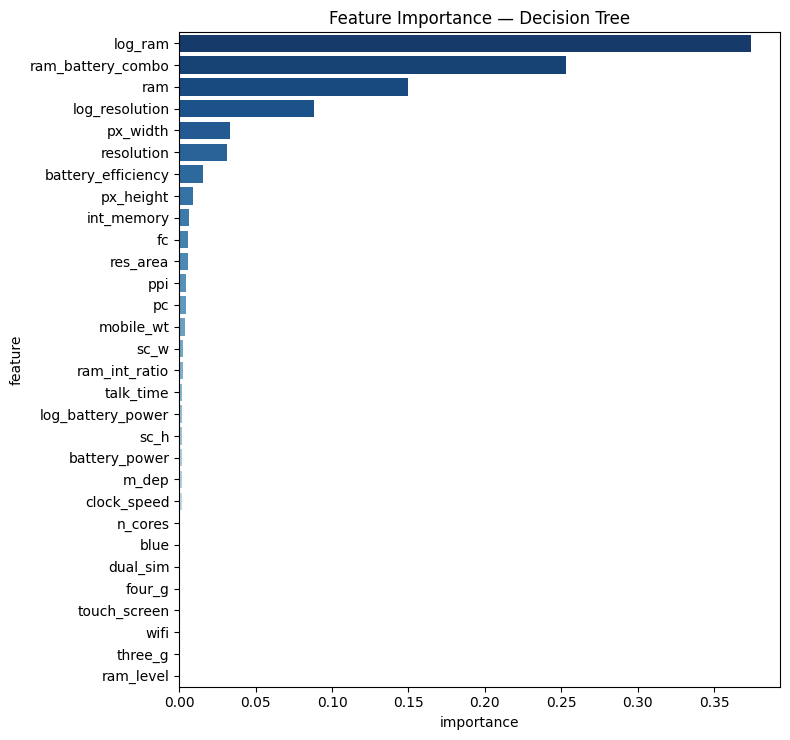

In [ ]:
# ===== FEATURE IMPORTANCE — DECISION TREE =====
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dt_model = best_estimators["DecisionTree"]

imp = dt_model.feature_importances_
df_dt = pd.DataFrame({
    "feature": X_train.columns,
    "importance": imp
}).sort_values("importance", ascending=False)

print(df_dt)

plt.figure(figsize=(8, max(4, 0.25 * len(df_dt))))
sns.barplot(x=df_dt["importance"], y=df_dt["feature"], palette="Blues_r")
plt.title("Feature Importance — Decision Tree")
plt.tight_layout()
plt.show()


STEP 5.3.3: RANDOM FOREST

               feature  importance
13                 ram    0.217628
28             log_ram    0.197485
24   ram_battery_combo    0.139595
26           ram_level    0.099619
23       ram_int_ratio    0.051250
29      log_resolution    0.030823
27   log_battery_power    0.029651
20          resolution    0.027391
12            px_width    0.026176
22  battery_efficiency    0.025868
0        battery_power    0.025477
11           px_height    0.021474
21                 ppi    0.014423
25            res_area    0.013769
6           int_memory    0.013590
8            mobile_wt    0.009704
15                sc_w    0.006838
7                m_dep    0.006715
16           talk_time    0.006701
10                  pc    0.006316
14                sc_h    0.006151
2          clock_speed    0.005520
4                   fc    0.005240
9              n_cores    0.005230
18        touch_screen    0.001541
1                 blue    0.001303
3             dual_sim    0.001219
5               four

/tmp/ipython-input-4173820460.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_rf["importance"], y=df_rf["feature"], palette="Greens_r")


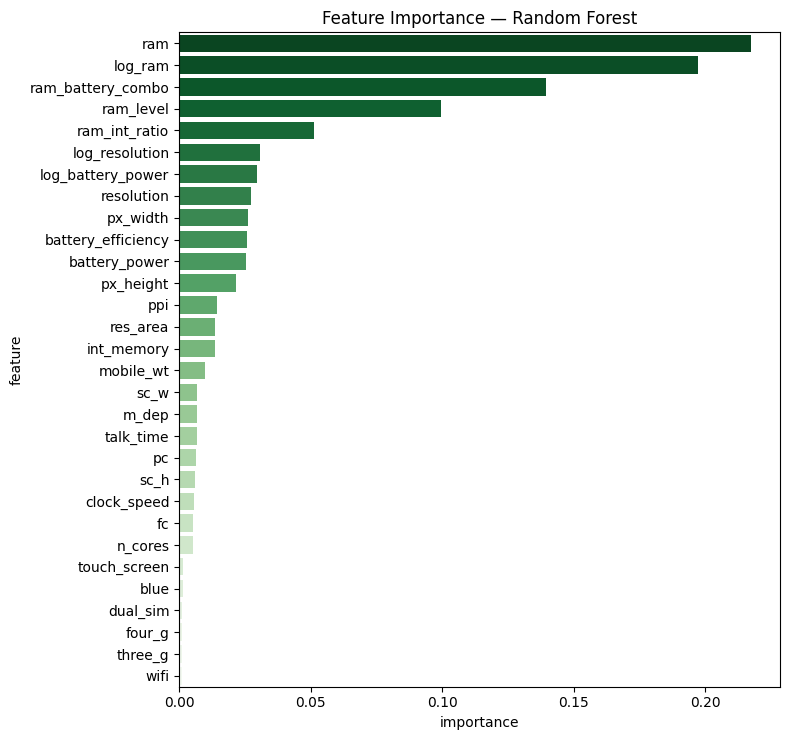

In [ ]:
# ===== FEATURE IMPORTANCE — RANDOM FOREST =====
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rf_model = best_estimators["RandomForest"]

imp = rf_model.feature_importances_
df_rf = pd.DataFrame({
    "feature": X_train.columns,
    "importance": imp
}).sort_values("importance", ascending=False)

print(df_rf)

plt.figure(figsize=(8, max(4, 0.25 * len(df_rf))))
sns.barplot(x=df_rf["importance"], y=df_rf["feature"], palette="Greens_r")
plt.title("Feature Importance — Random Forest")
plt.tight_layout()
plt.show()


STEP 5.3.5: KNN

Computing permutation importance for KNN…

KNN — Full Feature Importance Table:
           feature  importance
         ram_level    0.103750
               ram    0.092333
 ram_battery_combo    0.074250
           log_ram    0.070917
            four_g    0.026917
              wifi    0.008917
battery_efficiency    0.008833
         talk_time    0.007083
              blue    0.005417
           three_g    0.003750
           n_cores    0.003500
          px_width    0.003083
              sc_h    0.000750
               ppi    0.000083
     battery_power   -0.002167
          dual_sim   -0.004083
          res_area   -0.004250
                fc   -0.005417
         px_height   -0.005583
 log_battery_power   -0.005667
                pc   -0.006750
    log_resolution   -0.007417
         mobile_wt   -0.008250
             m_dep   -0.009083
       clock_speed   -0.009417
        resolution   -0.009500
     ram_int_ratio   -0.012250
      touch_screen   -0.012500
        int_memory   

/tmp/ipython-input-3858670937.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


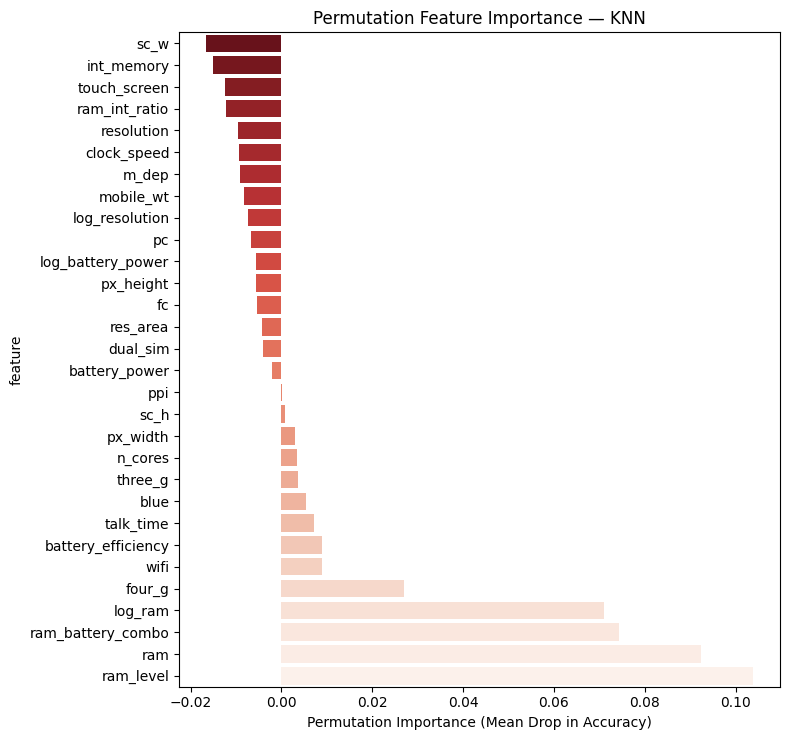

In [ ]:
# ===== PERMUTATION FEATURE IMPORTANCE — KNN (NO SAVING) =====
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

assert 'best_estimators' in globals(), "Run hypertuning first."
assert "KNN" in best_estimators, "KNN not found in best_estimators."
assert hasattr(X_train, "columns"), "X_train must be a DataFrame."

knn_model = best_estimators["KNN"]

print("Computing permutation importance for KNN…")

perm = permutation_importance(
    knn_model,
    X_test,
    y_test,
    n_repeats=30,          # repeat count for stability
    random_state=42,
    n_jobs=-1
)

importances = perm.importances_mean
df_knn_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\nKNN — Full Feature Importance Table:")
print(df_knn_imp.to_string(index=False))

# Plot all features
plt.figure(figsize=(8, max(4, 0.25 * len(df_knn_imp))))
sns.barplot(
    x=df_knn_imp["importance"][::-1],
    y=df_knn_imp["feature"][::-1],
    palette="Reds_r"
)
plt.xlabel("Permutation Importance (Mean Drop in Accuracy)")
plt.title("Permutation Feature Importance — KNN")
plt.tight_layout()
plt.show()



STEP 5.4: SCATTER PLOT

STEP 5.4.1: SGD LINEAR CLASSIFIER

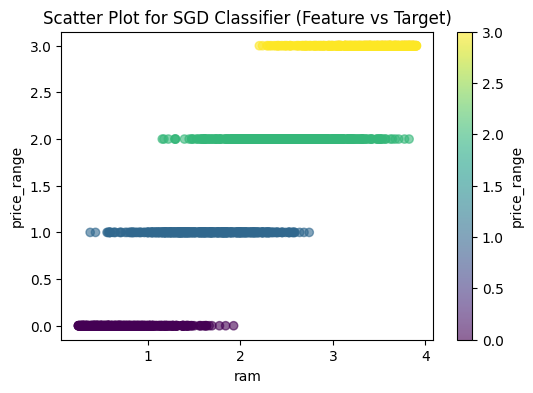

In [ ]:
import matplotlib.pyplot as plt

# choose one feature for scatter
feat1 = 'ram'

X1 = df[feat1]
y = df['price_range']

plt.figure(figsize=(6,4))
plt.scatter(X1, y, c=y, cmap='viridis', alpha=0.6)
plt.xlabel(feat1)
plt.ylabel("price_range")
plt.title("Scatter Plot for SGD Classifier (Feature vs Target)")
plt.colorbar(label="price_range")
plt.show()



STEP 5.4.2: LOGISTIC REGRESSON

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


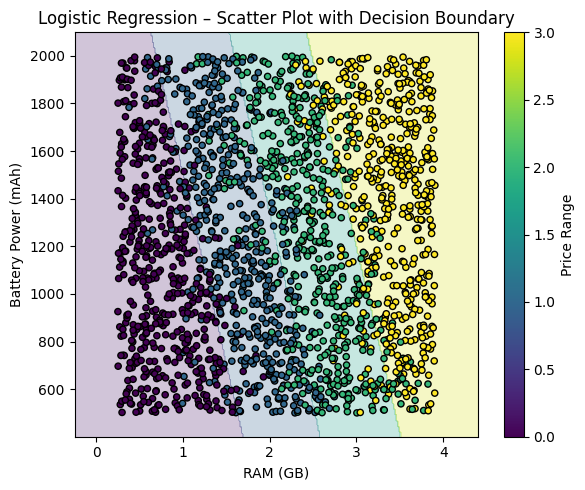

In [ ]:
# Scatter plot with decision boundary for Logistic Regression
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Use two features only (for visualization)
X2 = df[['ram', 'battery_power']]
y2 = df['price_range']

# Logistic Regression pipeline
log_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000))
])

# Train model
log_model.fit(X2, y2)

# Create mesh grid
x_min, x_max = X2['ram'].min() - 0.5, X2['ram'].max() + 0.5
y_min, y_max = X2['battery_power'].min() - 100, X2['battery_power'].max() + 100

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Predict on grid
Z = log_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, alpha=0.25, cmap='viridis')

# Scatter plot of actual data
scatter = plt.scatter(
    X2['ram'],
    X2['battery_power'],
    c=y2,
    cmap='viridis',
    s=20,
    edgecolor='k'
)

plt.xlabel("RAM (GB)")
plt.ylabel("Battery Power (mAh)")
plt.title("Logistic Regression – Scatter Plot with Decision Boundary")
plt.colorbar(scatter, label="Price Range")
plt.tight_layout()
plt.show()


STEP 5.4.3: DECISION TREE

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


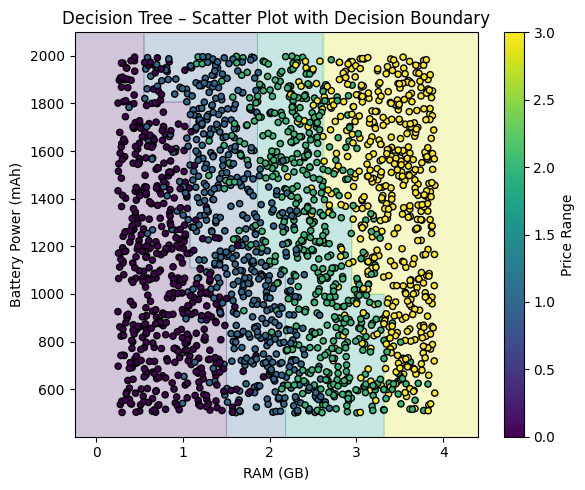

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# Use two features
X2 = df[['ram', 'battery_power']]
y2 = df['price_range']

# Train Decision Tree
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X2, y2)

# Mesh grid
x_min, x_max = X2['ram'].min() - 0.5, X2['ram'].max() + 0.5
y_min, y_max = X2['battery_power'].min() - 100, X2['battery_power'].max() + 100

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = dt_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, alpha=0.25, cmap='viridis')

plt.scatter(
    X2['ram'], X2['battery_power'],
    c=y2, cmap='viridis', s=20, edgecolor='k'
)

plt.xlabel("RAM (GB)")
plt.ylabel("Battery Power (mAh)")
plt.title("Decision Tree – Scatter Plot with Decision Boundary")
plt.colorbar(label="Price Range")
plt.tight_layout()
plt.show()


STEP 5.4.4: RANDOM FOREST

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


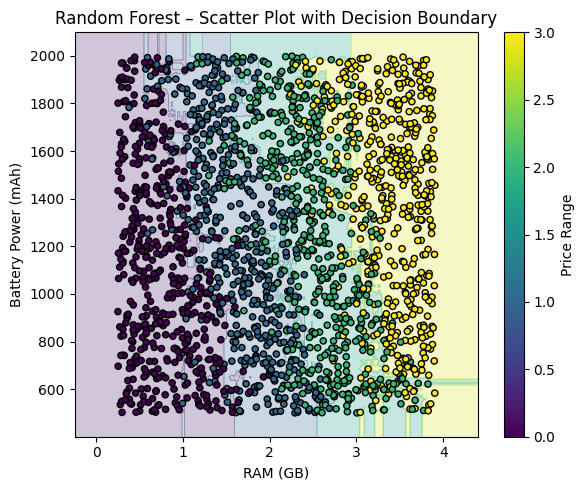

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X2, y2)

Z = rf_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, alpha=0.25, cmap='viridis')

plt.scatter(
    X2['ram'], X2['battery_power'],
    c=y2, cmap='viridis', s=20, edgecolor='k'
)

plt.xlabel("RAM (GB)")
plt.ylabel("Battery Power (mAh)")
plt.title("Random Forest – Scatter Plot with Decision Boundary")
plt.colorbar(label="Price Range")
plt.tight_layout()
plt.show()


STEP 5.4.5: KNN

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


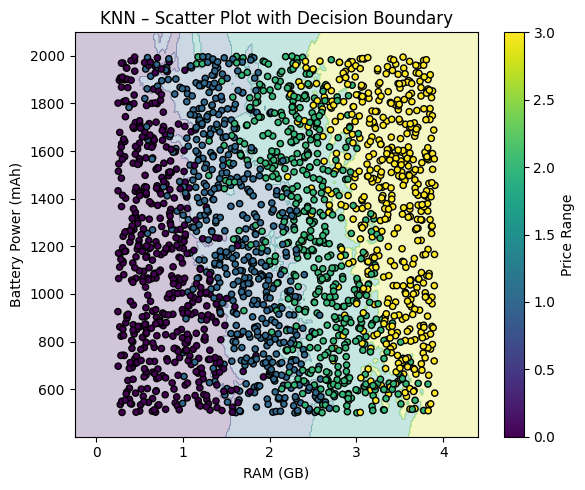

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Pipeline (KNN needs scaling)
knn_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X2, y2)

Z = knn_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, alpha=0.25, cmap='viridis')

plt.scatter(
    X2['ram'], X2['battery_power'],
    c=y2, cmap='viridis', s=20, edgecolor='k'
)

plt.xlabel("RAM (GB)")
plt.ylabel("Battery Power (mAh)")
plt.title("KNN – Scatter Plot with Decision Boundary")
plt.colorbar(label="Price Range")
plt.tight_layout()
plt.show()
